In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [104]:
df=pd.read_csv('/content/monthly_milk_production.csv')
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [106]:
df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

In [107]:
df['Month']=df.index.month

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
 1   Month       168 non-null    int32
dtypes: int32(1), int64(1)
memory usage: 3.3 KB


In [109]:
df.head()

,Production,Month
Date,,
1962-01-01,589,1
1962-02-01,561,2
1962-03-01,640,3
1962-04-01,656,4
1962-05-01,727,5


In [110]:
df.shape

(168, 2)

In [111]:
df.size

336

In [112]:
df.isnull().sum()

,0
Production,0
Month,0


In [113]:
df.duplicated().sum()

np.int64(0)

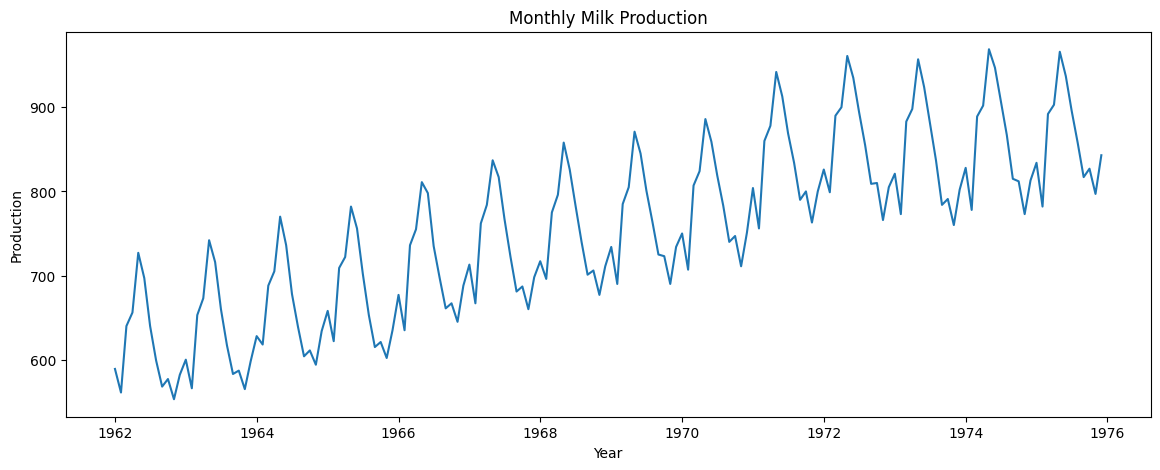

In [114]:
plt.figure(figsize=(14,5))
plt.plot(df['Production'])
plt.title('Monthly Milk Production')
plt.xlabel('Year')
plt.ylabel('Production')
plt.show()

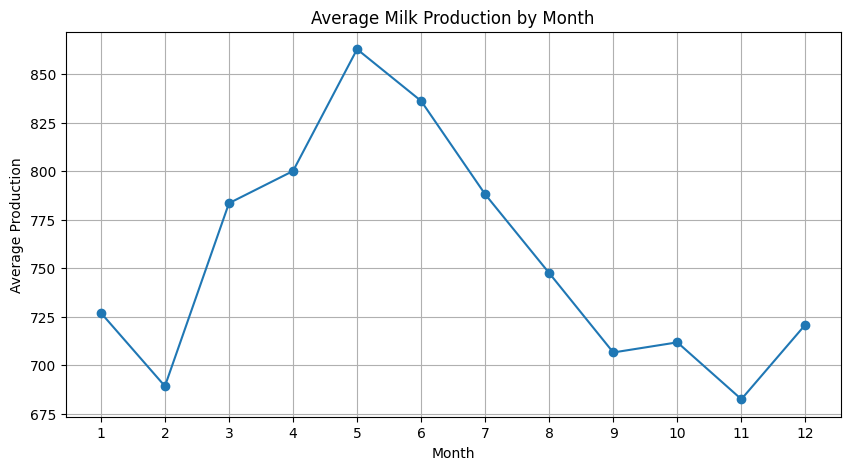

In [115]:

monthly_avg = df.groupby('Month')['Production'].mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.title("Average Milk Production by Month")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

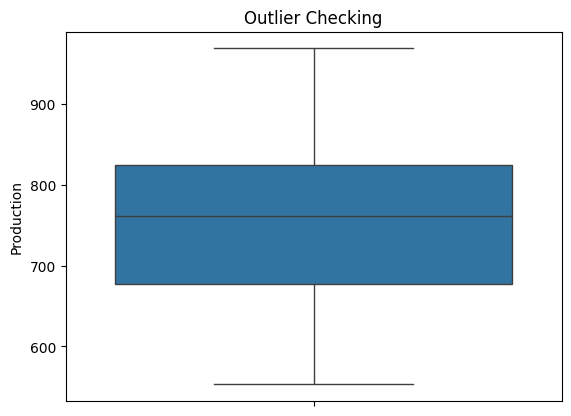

In [116]:
#Outlier checking
sns.boxplot(df['Production'])
plt.title("Outlier Checking")
plt.show()

In [117]:
data = df[['Production']].copy()
data.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [118]:
#Train-Validation_test split
n=len(data)
train_s=int(n*0.7)
val_s=int(n*0.15)

train=data.iloc[:train_s]
validation=data.iloc[train_s:train_s+val_s]
test=data.iloc[train_s+val_s:]
print("train:",train.shape)
print("validation:",validation.shape)
print("test:",test.shape)

train: (117, 1)
validation: (25, 1)
test: (26, 1)


In [119]:
#scale the data
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
train_scaled=scaler.fit_transform(train[['Production']])
val_scaled=scaler.transform(validation[['Production']])
test_scaled=scaler.transform(test[['Production']])

In [120]:
all_scaled=np.concatenate([
    train_scaled,
    val_scaled,
    test_scaled
])

In [121]:
#Create sequences for train,validation,test
train_end=len(train_scaled)
val_end=train_end+len(val_scaled)

x_train,y_train=create_sequences(
    train_scaled,
    window_size
)
val_input=all_scaled[train_end-window_size:val_end]

x_val,y_val=create_sequences(
    val_input,
    window_size
)

test_input=all_scaled[val_end-window_size:]
x_test,y_test=create_sequences(
    test_input,
    window_size
)

print("x_train:",x_train.shape)
print("y_train:",y_train.shape)
print("x_val:",x_val.shape)
print("y_val:",y_val.shape)
print("x_test:",x_test.shape)
print("y_test:",y_test.shape)

x_train: (1, 10, 1)
y_train: (1, 1)
x_val: (1, 10, 1)
y_val: (1, 1)
x_test: (1, 10, 1)
y_test: (1, 1)


In [122]:
#Basic RNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

rnn=Sequential()
rnn.add(SimpleRNN(64,activation='tanh',input_shape=(window_size,1)))
rnn.add(Dropout(0.2))
rnn.add(Dense(32,activation='relu'))
rnn.add(Dense(1))

In [123]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [124]:
#compile
rnn.compile(optimizer=Adam(learning_rate=0.001),loss='mse')
rnn.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
#Train
history_rnn=rnn.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=20,
    validation_data=(x_val,y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 2.2506e-05 - val_loss: 0.8299
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0070 - val_loss: 0.6985
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.0011 - val_loss: 0.6220
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.0043 - val_loss: 0.4971
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 8.3292e-04 - val_loss: 0.3854
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.0175 - val_loss: 0.3722
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - loss: 0.0200 - val_loss: 0.4203
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0050 - val_loss: 0.4893
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0072 - val_loss: 0.5135
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 1.6295e-05 - val_loss: 0.5347
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0047 - val_loss: 0.5134
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss

In [126]:
#Build the LSTM
from tensorflow.keras.layers import LSTM
lstm=Sequential()
lstm.add(LSTM(64,activation='tanh',input_shape=(window_size,1)))
lstm.add(Dropout(0.2))
lstm.add(Dense(32,activation='relu'))
lstm.add(Dense(1))

In [127]:
#Compile
lstm.compile(optimizer=Adam(learning_rate=0.001),loss='mse')
lstm.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
#Train
history_lstm=lstm.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=20,
    validation_data=(x_val,y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 7.3683e-04 - val_loss: 0.4107
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 6.0447e-05 - val_loss: 0.4699
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 2.7435e-04 - val_loss: 0.4783
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 1.7182e-04 - val_loss: 0.4726
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 6.3234e-05 - val_loss: 0.4589
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 6.2112e-04 - val_loss: 0.4339
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 1.9112e-04 - val_loss: 0.4035
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 2.2118e-04 - val_loss: 0.3902
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 1.2674e-04 - val_loss: 0.3855
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 5.6653e-04 - val_loss: 0.3918
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 1.7263e-05 - val_loss: 0.3992
Epoch 12/100
1/1 ━━━━━━━━━━━━━━

In [129]:
#Build the GRU
from tensorflow.keras.layers import GRU
gru=Sequential()
gru.add(GRU(64,activation='tanh',input_shape=(window_size,1)))
gru.add(Dropout(0.2))
gru.add(Dense(32,activation='relu'))
gru.add(Dense(1))

In [130]:
#Compile
gru.compile(optimizer=Adam(learning_rate=0.001),loss='mse')
gru.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [131]:
#Train
history_gru=gru.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=20,
    validation_data=(x_val,y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 6.4162e-04 - val_loss: 0.5220
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 4.4800e-05 - val_loss: 0.4709
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 4.5263e-08 - val_loss: 0.4352
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 3.7664e-05 - val_loss: 0.4204
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 4.0195e-05 - val_loss: 0.4135
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 2.0655e-04 - val_loss: 0.4205
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 4.9418e-05 - val_loss: 0.4370
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 2.0008e-05 - val_loss: 0.4532
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 7.3052e-06 - val_loss: 0.4653
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 4.7213e-05 - val_loss: 0.4664
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 1.2739e-04 - val_loss: 0.4606
Epoch 12/100
1/1 ━━━━━━━━━━━━━━

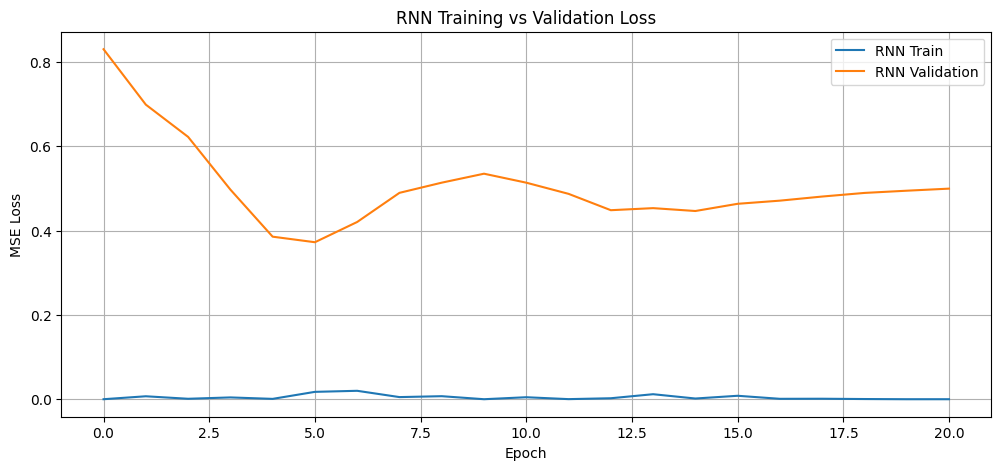

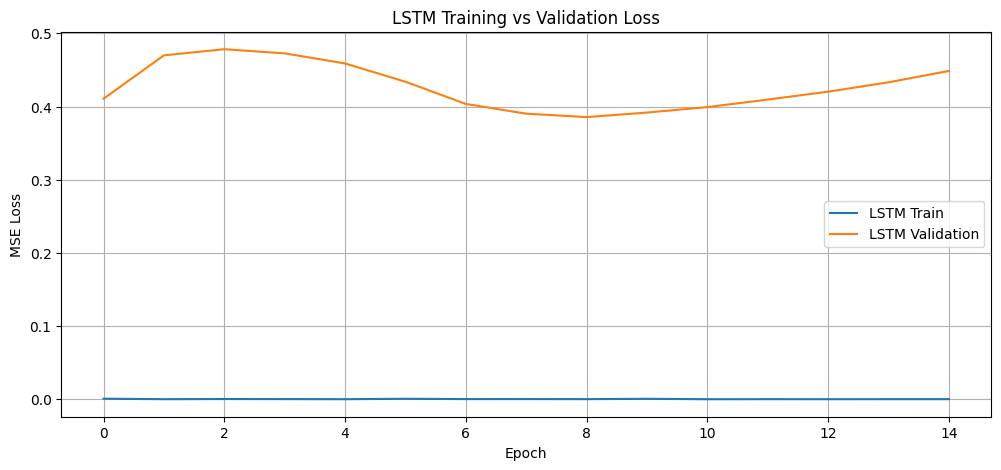

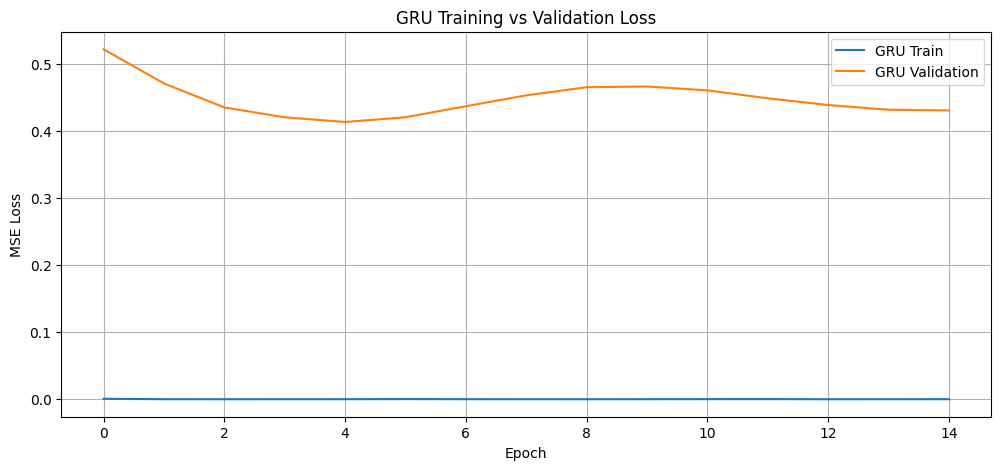

In [132]:
#Plotting the training and validation loss of RNN,LSTM and GRU
plt.figure(figsize=(12, 5))
plt.plot(history_rnn.history['loss'], label='RNN Train')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("RNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history_lstm.history['loss'], label='LSTM Train')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history_gru.history['loss'], label='GRU Train')
plt.plot(history_gru.history['val_loss'], label='GRU Validation')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [133]:
def get_predictions(model,x,y,scaler):
  pred_scaled=model.predict(x)
  pred=scaler.inverse_transform(pred_scaled)
  actual=scaler.inverse_transform(y.reshape(-1,1))
  return pred,actual.flatten(),pred.flatten()

In [134]:
def calclulate_metrics(actual,pred):
  mse=mean_squared_error(actual,pred)
  rmse=np.sqrt(mse)
  mae=mean_absolute_error(actual,pred)
  r2=r2_score(actual,pred)
  mape=np.mean(np.abs((actual-pred)/actual))*100
  return mse,rmse,mae,r2,mape

In [135]:
#Evaluation of RNN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_, actual_rnn, pred_rnn = get_predictions(
    rnn,
    x_test,
    y_test,
    scaler
)
rnn_mse, rnn_rmse, rnn_mae, rnn_r2, rnn_mape = calclulate_metrics(
    actual_rnn,
    pred_rnn
)
print("RNN Results:\n")
print("MSE:", rnn_mse)
print("RMSE:", rnn_rmse)
print("MAE:", rnn_mae)
print("R2:", rnn_r2)
print("MAPE:", rnn_mape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
RNN Results:

MSE: 37711.86680795252
RMSE: 194.1954345703125
MAE: 194.1954345703125
R2: nan
MAPE: 25.5520308645148


In [136]:
#Evaluation of LSTM
_, actual_lstm, pred_lstm = get_predictions(
    lstm,
    x_test,
    y_test,
    scaler)

lstm_mse, lstm_rmse, lstm_mae, lstm_r2, lstm_mape = calclulate_metrics(
    actual_lstm,
    pred_lstm
)
print("LSTM Results:\n")
print("MSE:", lstm_mse)
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("R2:", lstm_r2)
print("MAPE:", lstm_mape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
LSTM Results:

MSE: 43039.15422419086
RMSE: 207.45880126953125
MAE: 207.45880126953125
R2: nan
MAPE: 27.297210693359375


In [137]:
#Evalution of GRu
_,actual_gru, pred_gru = get_predictions(
    gru,
    x_test,
    y_test,
    scaler)

gru_mse, gru_rmse, gru_mae, gru_r2, gru_mape = calclulate_metrics(
    actual_gru,
    pred_gru
)

print("GRU Results:\n")
print("MSE:", gru_mse)
print("RMSE:", gru_rmse)
print("MAE:", gru_mae)
print("R2:", gru_r2)
print("MAPE:", gru_mape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
GRU Results:

MSE: 57095.212383806705
RMSE: 238.946044921875
MAE: 238.946044921875
R2: nan
MAPE: 31.440269068667764


In [138]:
#All model comparsin
results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, gru_mae],
    'MAPE': [rnn_mape, lstm_mape, gru_mape],
    'R2': [rnn_r2, lstm_r2, gru_r2],
    'MSE': [rnn_mse, lstm_mse, gru_mse]
})
print(results)

  Model        RMSE         MAE       MAPE  R2           MSE
0   RNN  194.195435  194.195435  25.552031 NaN  37711.866808
1  LSTM  207.458801  207.458801  27.297211 NaN  43039.154224
2   GRU  238.946045  238.946045  31.440269 NaN  57095.212384


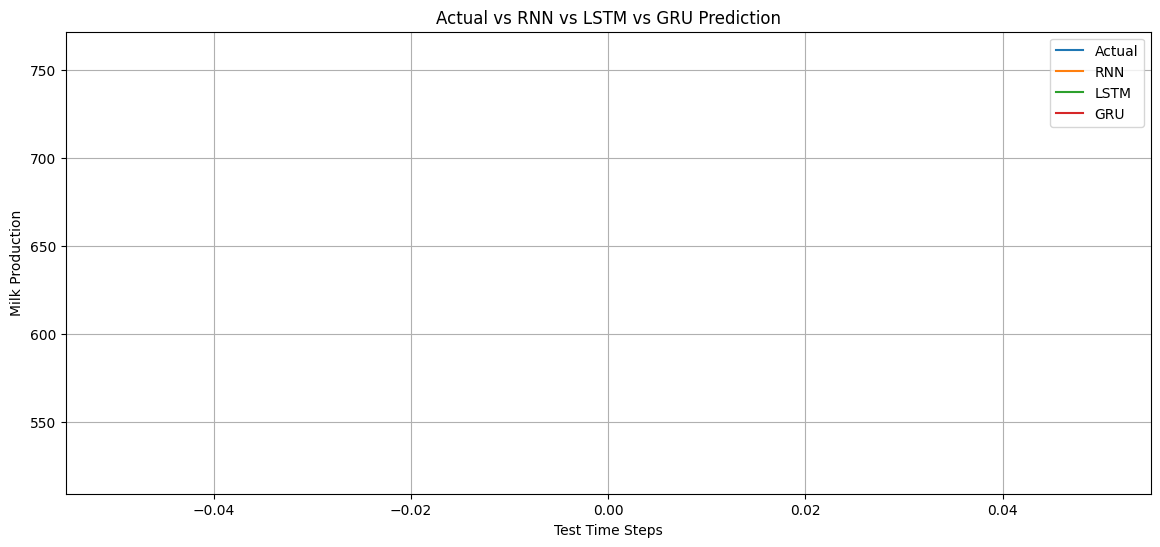

In [139]:
plt.figure(figsize=(14, 6))

plt.plot(actual_rnn,label='Actual')
plt.plot(pred_rnn,label='RNN')
plt.plot(pred_lstm,label='LSTM')
plt.plot(pred_gru,label='GRU')

plt.xlabel("Test Time Steps")
plt.ylabel("Milk Production")
plt.title("Actual vs RNN vs LSTM vs GRU Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [140]:
#Best model
models={
    'RNN':rnn,
    'LSTM':lstm,
    'GRU':gru
}

best_model_name=results.loc[
    results['RMSE'].idxmin(),
    'Model'
]

best_model=models[best_model_name]

print("Best model:",best_model_name)

Best model: RNN


In [141]:
best_model=rnn

In [142]:
#Recursiev forecasting function
def forecast_next12(model,data_scaled,scaler,window_size,n_months=12):
  current_seq=data_scaled[-window_size:]
  forecasted_values=[]

  for _ in range(n_months):
    input_data=current_seq.reshape(1,window_size,1)
    next_value=model.predict(
        input_data,
        verbose=0
    )[0,0]
    forecasted_values.append(next_value)
    current_seq=np.append(
        current_seq[1:],
        next_value
    )
  forecasted_values=scaler.inverse_transform(
      np.array(forecasted_values).reshape(-1,1)
  )
  return forecasted_values.flatten()


In [143]:
full_scaled=scaler.transform(
    data[['Production']]
)

In [144]:
forecast_next12=forecast_next12(
    best_model,
    full_scaled,
    scaler,
    window_size,
    n_months=12
)
print(forecast_next12)

[564.6519  495.24545 508.303   543.6714  546.2735  554.78595 539.5629
 526.9479  546.2822  606.89417 581.3112  589.8765 ]


In [145]:
#Create future dates
last_date=data.index[-1]
future_dates=pd.date_range(
    start=last_date+pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df=pd.DataFrame({
    'Date':future_dates,
    'Forecast':forecast_next12
})
print(forecast_df)

         Date    Forecast
0  1976-01-01  564.651917
1  1976-02-01  495.245453
2  1976-03-01  508.303009
3  1976-04-01  543.671387
4  1976-05-01  546.273499
5  1976-06-01  554.785950
6  1976-07-01  539.562927
7  1976-08-01  526.947876
8  1976-09-01  546.282227
9  1976-10-01  606.894165
10 1976-11-01  581.311218
11 1976-12-01  589.876526


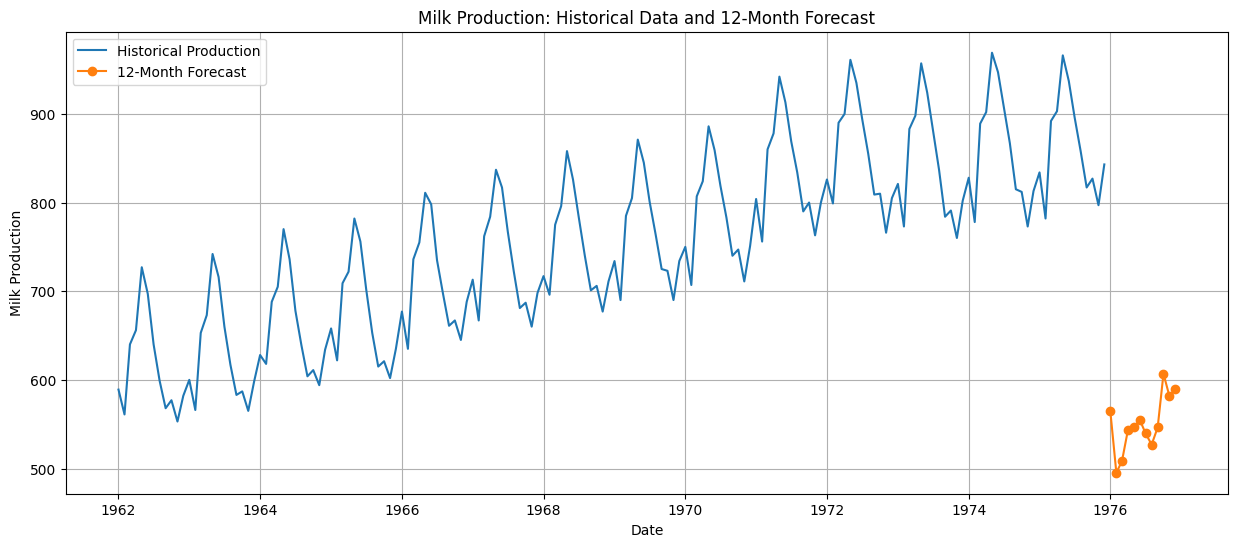

In [146]:
plt.figure(figsize=(15, 6))

plt.plot(
    data.index,
    data['Production'],
    label='Historical Production'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast'],
    marker='o',
    label='12-Month Forecast'
)

plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.title("Milk Production: Historical Data and 12-Month Forecast")
plt.legend()
plt.grid(True)
plt.show()

In [147]:
residuals = actual_lstm - pred_lstm

error_std = np.std(residuals)

forecast_df['Lower_Bound'] = (
    forecast_df['Forecast']
    - 1.96 * error_std
)

forecast_df['Upper_Bound'] = (
    forecast_df['Forecast']
    + 1.96 * error_std
)

print(forecast_df)

         Date    Forecast  Lower_Bound  Upper_Bound
0  1976-01-01  564.651917   564.651917   564.651917
1  1976-02-01  495.245453   495.245453   495.245453
2  1976-03-01  508.303009   508.303009   508.303009
3  1976-04-01  543.671387   543.671387   543.671387
4  1976-05-01  546.273499   546.273499   546.273499
5  1976-06-01  554.785950   554.785950   554.785950
6  1976-07-01  539.562927   539.562927   539.562927
7  1976-08-01  526.947876   526.947876   526.947876
8  1976-09-01  546.282227   546.282227   546.282227
9  1976-10-01  606.894165   606.894165   606.894165
10 1976-11-01  581.311218   581.311218   581.311218
11 1976-12-01  589.876526   589.876526   589.876526


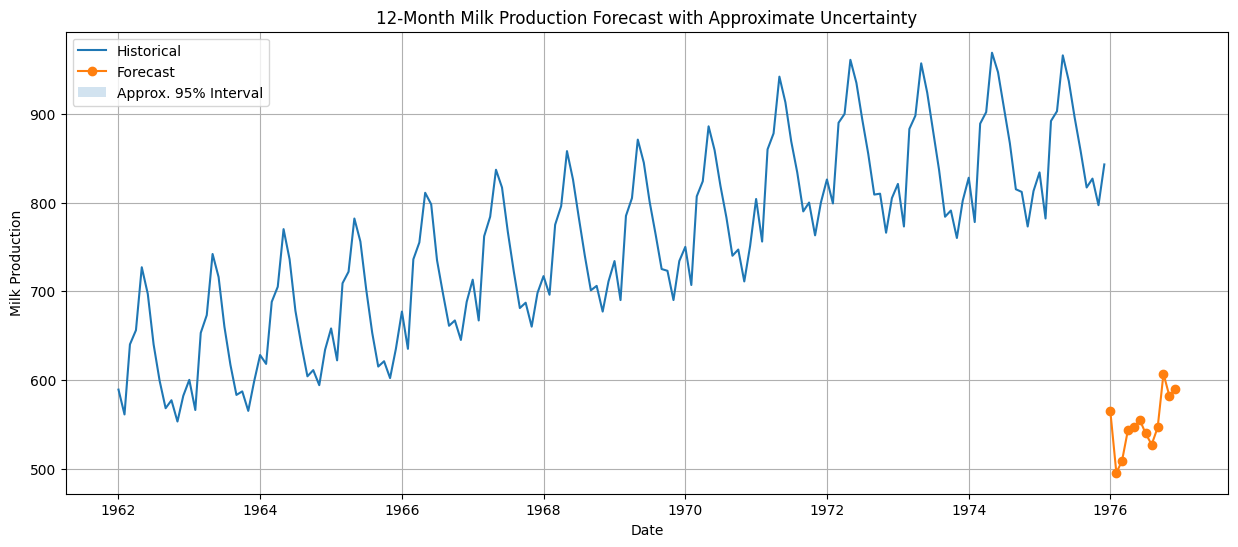

In [148]:
plt.figure(figsize=(15, 6))

plt.plot(
    data.index,
    data['Production'],
    label='Historical'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast'],
    marker='o',
    label='Forecast'
)

plt.fill_between(
    forecast_df['Date'],
    forecast_df['Lower_Bound'],
    forecast_df['Upper_Bound'],
    alpha=0.2,
    label='Approx. 95% Interval'
)

plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.title("12-Month Milk Production Forecast with Approximate Uncertainty")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
Business Insights:
1.Milk production is forecast to range from about 495 to 607 units in 1976.
2.February has the lowest forecast, while October has the highest.
3.Production generally increases toward the end of the year.
4.The dairy can use forecasts to plan feed, labor, and equipment efficiently.
5.Higher-production months require more storage, processing, and transportation capacity.
6.During lower-production months, the business can focus on maintenance and cost control.
7.Forecasts can support better inventory, sales, and financial planning.
8.The model should be improved by calculating a true 95% prediction interval for uncertainty.